In [1]:
#preserved concepts
!pip install numpy==1.26.4
import numpy as np
print(np.version.version)
!pip install pandas
import concept_getters
import pandas as pd
import re
import os
SPARSITY_RATIOS_LTH = [0.0, 20.0, 36.0, 48.8, 59.04, 67.232, 73.786, 79.028, 83.223, 86.578, 89.263, 91.41, 93.128, 94.502]
SPARSITY_RATIOS_WANDA = [0.0, 19.987, 35.97, 48.796, 59.017, 67.22, 73.763, 79.004, 83.203, 86.556, 89.258, 91.406, 93.099, 94.499]
expl_clus=3
import collections

def get_indiv_concepts_per_unit(df) -> dict:
    concepts = {}
    for unit,expl in zip(df.unit, df.best_name):
        concps = re.findall(r'(?<!\bNOT\s)(?:\b(?:hyp|pre|oth):[^\s)]+)', expl)
        for i in range(len(concps)):
            while concps[i][-1] == ')':
                concps[i] = concps[i][:-1]
        concepts[unit] = concps
    return concepts

def get_concepts_across_pruning_per_neuron(model, method, filename, sparsity_list,expl_clus):
    explanations = collections.defaultdict(list)
    sparsity_list = sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/"))
    for sparsity in sparsity_list:
        if '.ipy' in sparsity: continue
        sparsity = sparsity.split("%")[0]
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{sparsity}%Pruned/Cluster{expl_clus}IOUS1024N.csv")
        explanations[float(sparsity)] = get_indiv_concepts_per_unit(cluster3_expls) 
    reordered = collections.defaultdict(dict)
    for sparsity, neurons in explanations.items():
        for neuron, concepts in neurons.items():
            reordered[neuron][sparsity] = concepts
    return reordered 

def get_concepts_assoc_sparsities(model, method, filename, sparsity_list,expl_clus):
    explanations = collections.defaultdict(list)
    sparsity_list = sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/"))
    for sparsity in sparsity_list:
        if '.ipy' in sparsity: continue
        sparsity = sparsity.split("%")[0]
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{sparsity}%Pruned/Cluster{expl_clus}IOUS1024N.csv")
        explanations[float(sparsity)] = get_indiv_concepts_per_unit(cluster3_expls) 
    reordered = collections.defaultdict(lambda: collections.defaultdict(set))
    for sparsity, neurons in explanations.items():
        for neuron, concepts in neurons.items():
            for concept in concepts:
                reordered[neuron][concept].add(sparsity)
    return reordered 

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
  Obtaining dependency information for numpy==1.26.4 from https://files.pythonhosted.org/packages/4b/d7/ecf66c1cd12dc28b4040b15ab4d17b773b87fa9d29ca16125de01adb36cd/numpy-1.26.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 298.4 MB/s eta 0:00:000:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.22.2
    Uninstalling numpy-1.22.2:
      Successfully uninstalled numpy-1.22.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.57.1+1.g5fba9aa8f requires numpy<1.25,>=1.21, but you have numpy 1.26.4 which is incompatible.
torch-tensorrt 2.0.0.dev0 requires torch<=2.1.0,>=2.0.0, but you have torch 2.2.2 whi

In [2]:
lth_acc=pd.read_csv("/workspace/CCE_NLI/BERT/models/lottery_ticket/Run2Full/Accuracies/accuracy.csv")
for i,v in enumerate(lth_acc['Unnamed: 0']):
    newkey = int(v.split("_")[0])
    lth_acc['Unnamed: 0'].iloc[i] = newkey
accs = lth_acc.sort_values(by='Unnamed: 0')['0']
lth_acc= list(accs)

wanda_acc=pd.read_csv("/workspace/CCE_NLI/BERT/models/wanda/Run2Full/Accuracies/accuracy.csv")
for i,v in enumerate(wanda_acc['Unnamed: 0']):
    newkey = int(v.split("_")[0])
    wanda_acc['Unnamed: 0'].iloc[i] = newkey
accs = wanda_acc.sort_values(by='Unnamed: 0')['0']
wanda_acc=list(accs)

FileNotFoundError: [Errno 2] No such file or directory: '/workspace/CCE_NLI/BERT/models/lottery_ticket/Run2Full/Accuracies/accuracy.csv'

In [3]:
np.version.version

'1.26.4'

In [4]:
def count_frequencies(concepts_dict, neuron):
    concept_freq = []
    for list_of_concepts in concepts_dict[neuron].values():
        concept_freq.extend(list_of_concepts)
    concept_freq = collections.Counter(concept_freq)
    return {concept: freq for concept, freq in concept_freq.items() if freq > 5}
  

unique_concepts =set()
def num_unique_concepts_for_a_neuron(concepts_dict, neuron):
    concept_freq = []
    for list_of_concepts in concepts_dict[neuron].values():
        concept_freq.extend(list_of_concepts)
    concept_freq = collections.Counter(concept_freq)
    for concept in concept_freq:
        unique_concepts.add()
    return {concept: freq for concept, freq in concept_freq.items() if freq > 5}
                
        
        

In [5]:
list_of_repeated_concepts = set()
reordered = get_indiv_concepts_per_unit(df)
for neuron in reordered.keys():
    frequencies = count_frequencies(reordered,neuron)
    concepts = list(frequencies.keys())
    for c in concepts:
        list_of_repeated_concepts.add(c)


NameError: name 'df' is not defined

In [ ]:
len(list_of_repeated_concepts) 
#across all neurons and all iterations, 160 concepts repeat within a neuron at least 5 times 
#(meaning across 1024 neurons there are 106 uniue concepts where across pruning they are dominant 5/14 iterations ) 
#doesnt show whether they're dominant in begining/middle/end just that they're preserved 30% of iters for at least 1 neuron

In [ ]:
#graph for each neuron on avg how many concepts are repeated % of times
list_of_repeated_concepts = set()
unique = 0
for neuron in reordered.keys():
    frequencies = count_frequencies(reordered,neuron)
    num_u = num_unique_concepts_for_a_neuron(reordered,neuron)
    unique+=len(num_u)
    
    concepts = list(frequencies.keys())
num_u

# neuron wise: % of concepts preserved for at least first k iters
so for first 1 iters (ie only 1 iter 0.0%), should be 1.0 (all concepts are preserved for at least 1 iter)

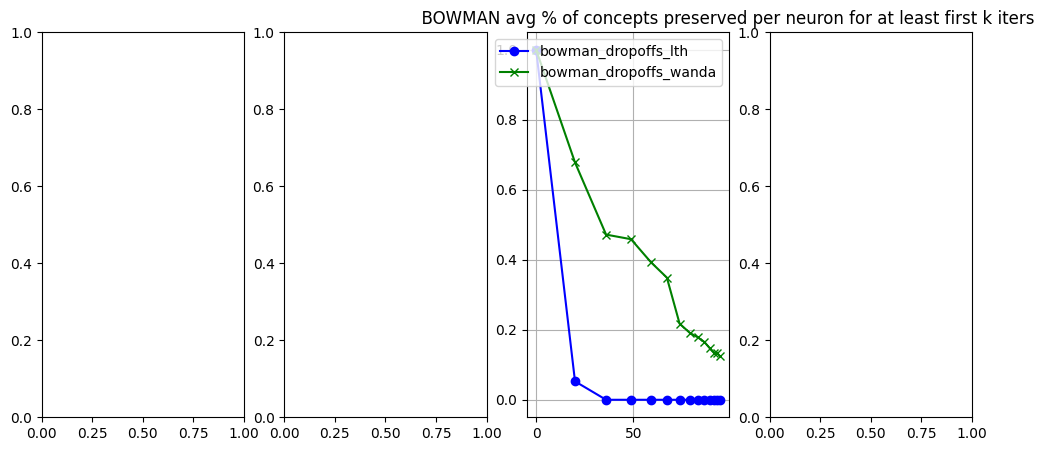

In [12]:
import matplotlib.pyplot as plt
expl_clus=3
def get_num_concpets_explained_originally(method, filename,expl_clus):
    unique_concepts=set()
    explanations = {}
    if filename == 'Random':
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/Expls/Cluster{expl_clus}IOUS1024N.csv")
        
    else:
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{0.0}%Pruned/Cluster{expl_clus}IOUS1024N.csv")
    
    all_concept_at_original = get_indiv_concepts_per_unit(cluster3_expls) 
    for neuron, concepts in all_concept_at_original.items():
        for concept in concepts:
            unique_concepts.add(concept)
    return len(unique_concepts) 



def dropoff(method, filename, k, **kwargs):
    num_orig_cps = kwargs['num_orig_cps']
    concept_and_assoc_sparsities = kwargs['concept_assoc_sparsity']
    sparsity_mapping = kwargs['neuron_concept_sparsity_mapping']

    percent_cocnepts_preserved=[]
    for neuron in sparsity_mapping.keys():
        concepts_preserved=set()
        for concept in concept_and_assoc_sparsities[neuron]:
            list_of_concepts_and_sprsty = list(concept_and_assoc_sparsities[neuron][concept])
            first_k_iters_present = sorted(list_of_concepts_and_sprsty)[:k]
            if first_k_iters_present == sparsity_list[:k]: #this concept is preserved for at lesat the first k iters
                concepts_preserved.add(concept)
        #print(neuron, len(concepts_preserved), len(sparsity_mapping[neuron][0.0]))
        if 0.0 in sparsity_mapping[neuron].keys():
            percent_cocnepts_preserved.append(len(concepts_preserved)/len(sparsity_mapping[neuron][0.0]))
        
    return sum(percent_cocnepts_preserved)/len(percent_cocnepts_preserved)
fig, axs = plt.subplots(1, 4, figsize=(12, 5))

def get_sparsities(model, method, filename):
    li=[]
    for s in sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/")):
        if '.ipy' in s: continue
        li.append(float(s.split("%")[0]))
    return li

x=[SPARSITY_RATIOS_WANDA[i] for i in range(0,14)] 


'''model="BERT"
bert_dropoffs_lth = []
method = 'lottery_ticket'
filename = 'Run3'
sparsity_list = get_sparsities(model, method, filename)
for k in range(1,15):
    num_orig_cps = get_num_concpets_explained_originally(method, filename,expl_clus)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename,sparsity_list,expl_clus)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename, sparsity_list,expl_clus)
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_cps=num_orig_cps, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bert_dropoffs_lth.append(percent_of_concepts_preserved)
    
    
bert_dropoffs_wanda = []
method = 'wanda'
filename = 'Run3'
sparsity_list = get_sparsities(model, method, filename)
for k in range(1,15):
    num_orig_cps = get_num_concpets_explained_originally(method, filename,expl_clus)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename,sparsity_list,expl_clus)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename, sparsity_list,expl_clus)
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_cps=num_orig_cps, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bert_dropoffs_wanda.append(percent_of_concepts_preserved)
    

axs[0].plot(x, bert_dropoffs_lth, label='bert_dropoffs_lth', color='blue',marker='o')
axs[0].plot(x, bert_dropoffs_wanda, label='bert_dropoffs_wanda', color='green',marker='x')
axs[0].set_title('BERT avg % of concepts preserved per neuron\n for at least first k iters')
axs[0].legend()
axs[0].grid(True)


model="BERT"
bert_dropoffs_lth_2 = []
method = 'lottery_ticket'
filename = 'Run2Full'
sparsity_list = get_sparsities(model, method, filename)
for k in range(1,15):
    num_orig_cps = get_num_concpets_explained_originally(method, filename,expl_clus)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename, sparsity_list,expl_clus)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename, sparsity_list,expl_clus)
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_cps=num_orig_cps, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bert_dropoffs_lth_2.append(percent_of_concepts_preserved)
    
    
bert_dropoffs_wanda_2 = []
method = 'wanda'
filename = 'Run2Full'
sparsity_list = get_sparsities(model, method, filename)
for k in range(1,15):
    num_orig_cps = get_num_concpets_explained_originally(method, filename,expl_clus)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename, sparsity_list,expl_clus)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename, sparsity_list,expl_clus)
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_cps=num_orig_cps, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bert_dropoffs_wanda_2.append(percent_of_concepts_preserved)
    
bert_dropoffs_lth = [(x+y)/2 for x,y in zip(bert_dropoffs_lth, bert_dropoffs_lth_2)]
bert_dropoffs_wanda = [(x+y)/2 for x,y in zip(bert_dropoffs_wanda, bert_dropoffs_wanda_2)]


axs[1].plot(x, bert_dropoffs_lth, label='bert_dropoffs_lth', color='blue',marker='o')
axs[1].plot(x, bert_dropoffs_wanda, label='bert_dropoffs_wanda', color='green',marker='x')
axs[1].set_title(f'Cluster {expl_clus}\nBERT averaged results of Run1 and 2\n% of concepts preserved per neuron\n for at least first k iters')
axs[1].legend()
axs[1].grid(True)

'''

model="BOWMAN"
bowman_dropoffs_lth = []
method = 'lottery_ticket'
filename = 'Run1'
sparsity_list = get_sparsities(model, method, filename)
for k in range(1,15):
    num_orig_cps = get_num_concpets_explained_originally(method, filename,expl_clus)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename,sparsity_list, expl_clus)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename,sparsity_list, expl_clus)
    #print(f"\n\n{concept_assoc_sparsity}")
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_cps=num_orig_cps, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bowman_dropoffs_lth.append(percent_of_concepts_preserved)
    
    
bowman_dropoffs_wanda = []
method = 'wanda'
filename = 'Run1'


sparsity_list = get_sparsities(model, method, filename)
for k in range(1,15):
    num_orig_cps = get_num_concpets_explained_originally(method, filename,expl_clus)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename,sparsity_list,expl_clus)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename,sparsity_list, expl_clus)
    #print(f"\n\n{concept_assoc_sparsity}")
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_cps=num_orig_cps, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bowman_dropoffs_wanda.append(percent_of_concepts_preserved)
    


axs[2].plot(x, bowman_dropoffs_lth, label='bowman_dropoffs_lth', color='blue',marker='o')
axs[2].plot(x, bowman_dropoffs_wanda, label='bowman_dropoffs_wanda', color='green',marker='x')
axs[2].set_title('                                      BOWMAN avg % of concepts preserved per neuron for at least first k iters')
axs[2].legend()
axs[2].grid(True)



#so ex 30% of concepts make it to the 3rd pruning iter staying with the same neuron
    
  

# % of neurons that preserve concepts for at lesat first k iters

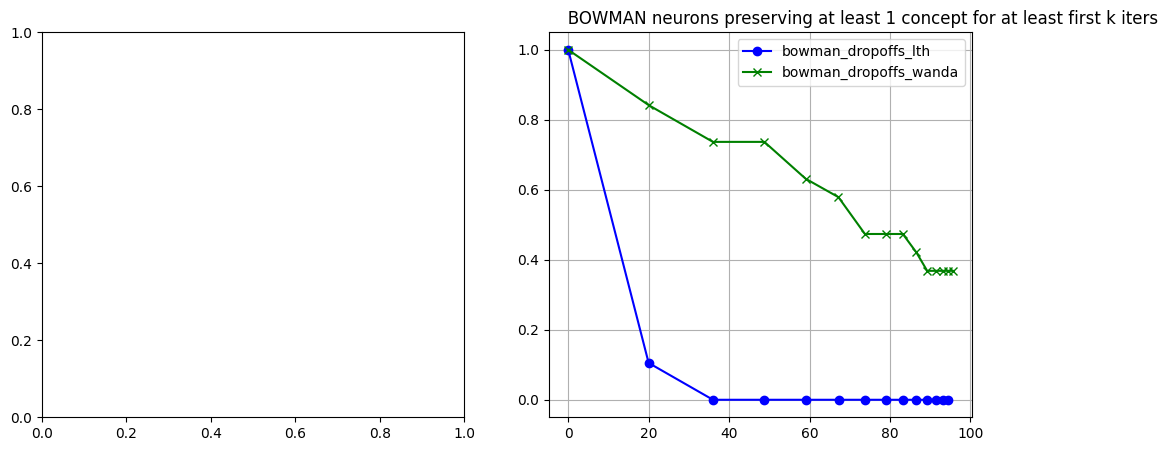

In [13]:
import torch
def get_neurons_explained_originally(model, method, filename, expl_clus):
    unique_concepts=set()
    explanations = {}
    if filename == 'Random':
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/Expls/Cluster{expl_clus}IOUS1024N.csv")
    else:
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{0.0}%Pruned/Cluster{expl_clus}IOUS1024N.csv")
    
    all_concept_at_original = get_indiv_concepts_per_unit(cluster3_expls) 
    return len(list(all_concept_at_original.keys()))

def get_sparsity_list(model, method, filename):
    sparsities = []
    sparsity_list = sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/"))
    for sparsity in sparsity_list:
        if '.ipy' in sparsity: continue
        sparsity = sparsity.split("%")[0]
        sparsities.append(float(sparsity))
    return sorted(sparsities)
        
def dropoff(method, filename, k, **kwargs):
    sparsity_list = get_sparsity_list(model, method, filename)
    num_orig_neurons = kwargs['num_orig_neurons']
    concept_and_assoc_sparsities = kwargs['concept_assoc_sparsity']
    sparsity_mapping = kwargs['neuron_concept_sparsity_mapping']
    neurons_preserved = [False for i in range(num_orig_neurons)]
    for i,neuron in enumerate(sparsity_mapping.keys()):
        for concept in concept_and_assoc_sparsities[neuron]:
            list_of_concepts_and_sprsty = list(concept_and_assoc_sparsities[neuron][concept])
            first_k_iters_present = sorted(list_of_concepts_and_sprsty)[:k]
            if first_k_iters_present == sparsity_list[:k]: #this concept is preserved for at lesat the first 6 iters
                neurons_preserved[i] = True
                break
    return torch.where(torch.tensor(neurons_preserved)==1, 1,0).sum()/num_orig_neurons


expl_clus=3
    
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
x=[SPARSITY_RATIOS_WANDA[i] for i in range(0,14)] 
'''
model="BERT"
bert_dropoffs_lth = []
method = 'lottery_ticket'
filename = 'Run2Full'
sparsity_list = get_sparsities(model, method, filename)
for k in range(1,15):
    num_orig_neurons = get_neurons_explained_originally(model, method, filename,expl_clus)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename,sparsity_list,expl_clus)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename,sparsity_list,expl_clus)
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_neurons=num_orig_neurons, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bert_dropoffs_lth.append(percent_of_concepts_preserved)

    
bert_dropoffs_wanda = []
method = 'wanda'
filename = 'Run2Full'
sparsity_list = get_sparsities(model, method, filename)
for k in range(1,15):
    num_orig_neurons = get_neurons_explained_originally(model, method, filename,expl_clus)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename,sparsity_list,expl_clus)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename,sparsity_list,expl_clus)
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_neurons=num_orig_neurons, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bert_dropoffs_wanda.append(percent_of_concepts_preserved)
    


axs[0].plot(x, bert_dropoffs_lth, label='bert_dropoffs_lth', color='blue',marker='o')
axs[0].plot(x, bert_dropoffs_wanda, label='bert_dropoffs_wanda', color='green',marker='x')
axs[0].set_title(f'Cluster: {expl_clus}\n BERT % of neurons preserving\n at least 1 concept for at least\n first k iters')
axs[0].legend()
axs[0].grid(True)



'''
model="BOWMAN"
bowman_dropoffs_lth = []
method = 'lottery_ticket'
filename = 'Run1'
sparsity_list_l = get_sparsities(model, method, filename)
for k in range(1,len(sparsity_list_l)+1):
    num_orig_neurons = get_neurons_explained_originally(model, method, filename,expl_clus)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename,sparsity_list_l,expl_clus)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename,sparsity_list_l,expl_clus)
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_neurons=num_orig_neurons, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bowman_dropoffs_lth.append(percent_of_concepts_preserved)
    
    
bowman_dropoffs_wanda = []
method = 'wanda'
filename = 'Run1'
sparsity_list_w = get_sparsities(model, method, filename)
for k in range(1,len(sparsity_list_w)+1):
    num_orig_neurons = get_neurons_explained_originally(model, method, filename,expl_clus)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename,sparsity_list_w,expl_clus)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename,sparsity_list_w,expl_clus)
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_neurons=num_orig_neurons, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bowman_dropoffs_wanda.append(percent_of_concepts_preserved)
    

axs[1].plot(sparsity_list_l, bowman_dropoffs_lth, label='bowman_dropoffs_lth', color='blue',marker='o')
axs[1].plot(sparsity_list_w, bowman_dropoffs_wanda, label='bowman_dropoffs_wanda', color='green',marker='x')
axs[1].set_title('                                       BOWMAN neurons preserving at least 1 concept for at least first k iters')
axs[1].legend()
axs[1].grid(True)



#65% of neurons preserve concepts for at least 3 pruning iters
#shows that for bert more single neurons preserve concepts 

# global overlap: % of concepts that are preserved in kth pruning iter compared to original

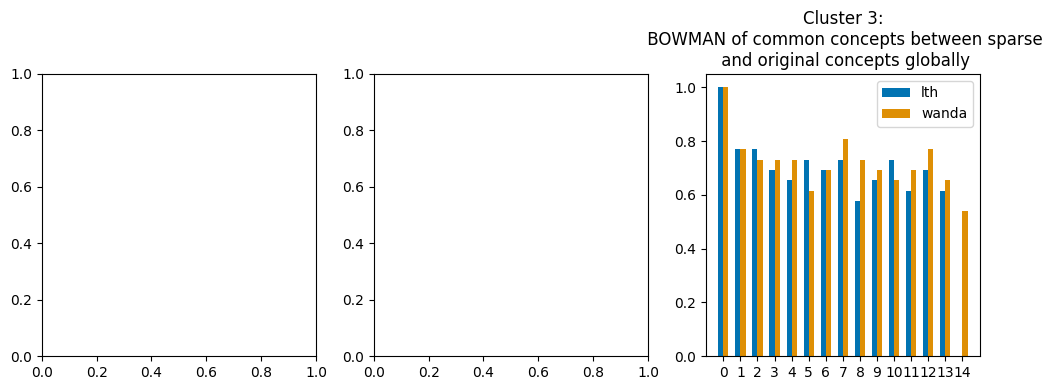

In [15]:
import os
import matplotlib.pyplot as plt
import numpy as np
expl_clus=3
def get_concepts_across_cluster(model, method, filename,expl_clus):
    explanations = collections.defaultdict(set)
    sparsity_list = sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/"))
    for sparsity in sparsity_list:
        if '.ipy' in sparsity: continue
        sparsity = sparsity.split("%")[0]
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{sparsity}%Pruned/Cluster{expl_clus}IOUS1024N.csv")
        for _,concepts in get_indiv_concepts_per_unit(cluster3_expls).items():
            explanations[float(sparsity)].update(concepts)
    return explanations
def overlap(cur, base):
    
    
    intersection = len(cur.intersection(base))
    #union = len(cur.union(base))
    #return percent overlap
    return intersection/len(base)
    return intersection / union if union > 0 else 0



fig, axs = plt.subplots(1, 3, figsize=(10, 4))  # 1 row, 2 columns
'''   
pretrained_concepts = set()
for concepts in get_indiv_concepts_per_unit(pd.read_csv(f"/workspace/CCE_NLI/BERT/exp/PretrainedWeights/expls/Cluster{expl_clus}IOUS1024N.csv")).values():
    pretrained_concepts.update(concepts)
    
method='wanda'
filename='Run3'
model='BERT'
global_concepts = get_concepts_across_cluster(model,method, filename,expl_clus)
base_concepts = global_concepts[0.0]
bert_overlap_between_sparse_and_pretrained_wanda=[]
bert_overlap_between_sparse_and_base_wanda= []
for sparsity in global_concepts:
    bert_overlap_between_sparse_and_base_wanda.append(overlap(global_concepts[sparsity], base_concepts))
    bert_overlap_between_sparse_and_pretrained_wanda.append(overlap(global_concepts[sparsity], pretrained_concepts))

method='lottery_ticket'
filename='Run3'
model='BERT'
global_concepts = get_concepts_across_cluster(model, method, filename,expl_clus)
global_concepts_lth=global_concepts
base_concepts = global_concepts[0.0]

bert_overlap_between_sparse_and_base_lth= []
bert_overlap_between_sparse_and_pretrained_lth = []
for sparsity in global_concepts:
    bert_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], base_concepts))
    bert_overlap_between_sparse_and_pretrained_lth.append(overlap(global_concepts[sparsity], pretrained_concepts))

x=get_sparsities(model, method, filename)
x_pos_l = np.arange(len(x))  # Numeric positions for bars
bar_width = 0.3
# First plot


axs[0].plot(bert_overlap_between_sparse_and_base_lth, label='lth', color='#0173b2',marker='o')
axs[0].plot(bert_overlap_between_sparse_and_base_wanda, label='wanda', color='#de8f05',marker='x')
axs[0].set_title(f'Cluster {expl_clus}:\n BERT % of common concepts\n between sparse\n and original concepts globally')
axs[0].legend()
axs[0].grid(True, axis='y', linestyle='--', alpha=0.7)
axs[0].set_xticks(x_pos_l)
axs[0].set_xticklabels(x, rotation=90, ha='right')

axs[1].plot(wanda_acc, label='wanda_acc', color='#FF0000',marker='+')
axs[1].plot(lth_acc, label='lth_acc', color='#2ca02c',marker='*')
axs[1].legend()
axs[1].set_title('Accuracies')
axs[1].grid(True, axis='y', linestyle='--', alpha=0.7)
axs[1].set_xticks(x_pos_l)
axs[1].set_xticklabels(x, rotation=90, ha='right')

# First plot
axs[2].plot(x_pos_l - bar_width/2, bert_overlap_between_sparse_and_pretrained_lth, label='lth', color='#0173b2',marker='o')
axs[2].plot(x_pos_l + bar_width/2, bert_overlap_between_sparse_and_pretrained_wanda, label='wanda', color='#de8f05',marker='x')
axs[2].set_title(f'Cluster {expl_clus}:\n BERT % of common concepts\n between sparse\n and default rules globally')
axs[2].legend()
axs[2].grid(True, axis='y', linestyle='--', alpha=0.7)
axs[2].set_xticks(x_pos_l)
axs[2].set_xticklabels(x, rotation=90, ha='right')
''' 
method='wanda'
filename='Run1'
model='BOWMAN'
        
x_w=get_sparsities(model, method, filename)
x_pos_w = np.arange(len(x_w))  # Numeric positions for bars

global_concepts = get_concepts_across_cluster(model,method, filename,expl_clus)
base_concepts = global_concepts[0.0]
bowman_overlap_between_sparse_and_base_wanda= []
for sparsity in global_concepts:
    bowman_overlap_between_sparse_and_base_wanda.append(overlap(global_concepts[sparsity], base_concepts))
    
method='lottery_ticket'
filename='Run1'
model='BOWMAN'
global_concepts = get_concepts_across_cluster(model, method, filename,expl_clus)
base_concepts = global_concepts[0.0]
bowman_overlap_between_sparse_and_base_lth= []
for sparsity in global_concepts:
    bowman_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], base_concepts))
        
x=get_sparsities(model, method, filename)
x_pos_l = np.arange(len(x))  # Numeric positions for bars

bar_width = 0.3


# Second plot
axs[2].bar(x_pos_l- bar_width/2, bowman_overlap_between_sparse_and_base_lth, label='lth',color='#0173b2', width=bar_width)
axs[2].bar(x_pos_w+bar_width/2, bowman_overlap_between_sparse_and_base_wanda, label='wanda',color='#de8f05', width=bar_width)
axs[2].set_title(f'Cluster {expl_clus}:\n BOWMAN of common concepts between sparse\n and original concepts globally')
axs[2].set_xticks(x_pos_w)
axs[2].legend()

plt.tight_layout()
plt.show()


67 is where wanda acc drops down to 33% and thats where the overlap with the default starts losing consistency 
as acc drops the wanda alignemnt w default increases then when the acc plateaus staying around 33 the alignment with default rules fluctuates

lottery consistently has lower alginment with default 

this is global alignment what about neuron wise alignemnt (do next cl


In [123]:
df=pd.read_csv("/workspace/CCE_NLI/BERT/exp/PretrainedWeights/Expls/Cluster3IOUS1024N.csv")
default_cps_per_neuron = get_indiv_concepts_per_unit(df)


In [102]:
len(global_concepts_lth[91.41]), len(pretrained_concepts)

(373, 215)

[Text(0, 0, '0.0'),
 Text(1, 0, '19.971'),
 Text(2, 0, '35.986'),
 Text(3, 0, '48.779'),
 Text(4, 0, '59.033'),
 Text(5, 0, '67.188'),
 Text(6, 0, '73.779'),
 Text(7, 0, '79.004'),
 Text(8, 0, '83.203'),
 Text(9, 0, '86.572'),
 Text(10, 0, '89.258'),
 Text(11, 0, '91.406'),
 Text(12, 0, '93.115'),
 Text(13, 0, '94.482'),
 Text(14, 0, '95.557')]

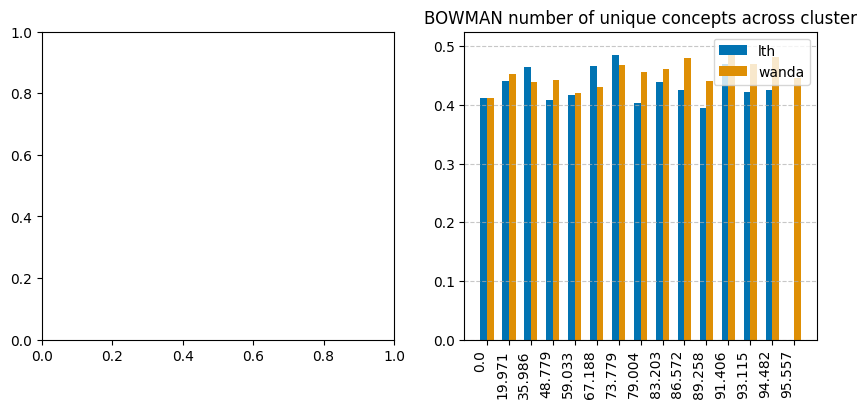

In [17]:
def get_number_of_unique_concepts_global(df):
    concepts=set()
    total = []
    for neuron,expls in get_indiv_concepts_per_unit(df).items():
        concepts.update(expls)
        total.extend(expls)
    return len(concepts), len(total)

def get_num_concepts_across_cluster(model, method, filename):
    explanations = []
    sparsity_list = sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/"))
    for sparsity in sparsity_list:
        if '.ipy' in sparsity: continue
        sparsity = sparsity.split("%")[0]
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{sparsity}%Pruned/Cluster{expl_clus}IOUS1024N.csv")
        num_unique, total = get_number_of_unique_concepts_global(cluster3_expls)
        explanations.append(num_unique/total)
    return explanations
import numpy as np

fig, axs = plt.subplots(1,2, figsize=(10, 4))  # 1 row, 2 columns


bar_width = 0.3
'''
model='BERT'
method='lottery_ticket'
filename='Run3'
x_axis=get_sparsities(model, method, filename)        
x_pos = np.arange(len(x_axis))  # Numeric positions for bars
# Plot grouped bars with offsets
axs[0].bar(x_pos - bar_width/2, get_num_concepts_across_cluster(model, method, filename), 
           label='lth', color='#0173b2', width=bar_width)

        
model='BERT'        
method='wanda'
filename='Run3'
x_axis=get_sparsities(model, method, filename)        
x_pos = np.arange(len(x_axis))  # Numeric positions for bars
axs[0].bar(x_pos + bar_width/2, get_num_concepts_across_cluster(model, method, filename), 
           label='wanda',color='#de8f05', width=bar_width)


axs[0].set_title('BERT % of unique concepts across cluster')
axs[0].legend()
axs[0].grid(True, axis='y', linestyle='--', alpha=0.7)
axs[0].set_xticks(x_pos)
axs[0].set_xticklabels(x_axis, rotation=90, ha='right')
'''
model='BOWMAN'
method='lottery_ticket'
filename='Run1'
x=get_sparsities(model, method, filename)
x_axis=get_sparsities(model, method, filename)        
x_pos = np.arange(len(x_axis))  # Numeric positions for bars
# Plot grouped bars with offsets
axs[1].bar(x_pos - bar_width/2, get_num_concepts_across_cluster(model, method, filename), 
           label='lth', color='#0173b2', width=bar_width)

        
model='BOWMAN'        
method='wanda'
filename='Run1'
x_axis=get_sparsities(model, method, filename)        
x_pos = np.arange(len(x_axis))  # Numeric positions for bars
axs[1].bar(x_pos + bar_width/2, get_num_concepts_across_cluster(model, method, filename), 
           label='wanda',color='#de8f05', width=bar_width)

axs[1].set_title('BOWMAN number of unique concepts across cluster')
axs[1].legend()
axs[1].grid(True, axis='y', linestyle='--', alpha=0.7)
axs[1].set_xticks(x_pos)
axs[1].set_xticklabels(x_axis, rotation=90, ha='right')


In [ ]:
#every iteration is 55% similar to the concepts in the original
#with wanda its expectedly reducing in similar (wb increase at 86)

# globally: % of concepts preserved in kth pruning iter compared to the one prior to it 

wanda 83.203 41
wanda 86.572 36
26 26 1.0
20 39 0.5128205128205128
25 41 0.6097560975609756
26 42 0.6190476190476191
28 44 0.6363636363636364
28 46 0.6086956521739131
27 46 0.5869565217391305
30 48 0.625
30 53 0.5660377358490566
29 48 0.6041666666666666
25 48 0.5208333333333334
29 51 0.5686274509803921
25 57 0.43859649122807015
25 53 0.4716981132075472
26 54 0.48148148148148145
lottery_ticket 83.223 73
lottery_ticket 86.578 69
26 26 1.0
20 54 0.37037037037037035
26 76 0.34210526315789475
19 80 0.2375
22 71 0.30985915492957744
26 78 0.3333333333333333
25 81 0.30864197530864196
28 87 0.3218390804597701
27 111 0.24324324324324326
32 110 0.2909090909090909
36 100 0.36
30 113 0.26548672566371684
36 111 0.32432432432432434
43 126 0.3412698412698413


[Text(0, 0, '0.0/0.0'),
 Text(1, 0, '0.0/19.971'),
 Text(2, 0, '19.971/35.986'),
 Text(3, 0, '35.986/48.779'),
 Text(4, 0, '48.779/59.033'),
 Text(5, 0, '59.033/67.188'),
 Text(6, 0, '67.188/73.779'),
 Text(7, 0, '73.779/79.004'),
 Text(8, 0, '79.004/83.203'),
 Text(9, 0, '83.203/86.572'),
 Text(10, 0, '86.572/89.258'),
 Text(11, 0, '89.258/91.406'),
 Text(12, 0, '91.406/93.115'),
 Text(13, 0, '93.115/94.482'),
 Text(14, 0, '94.482/95.557')]

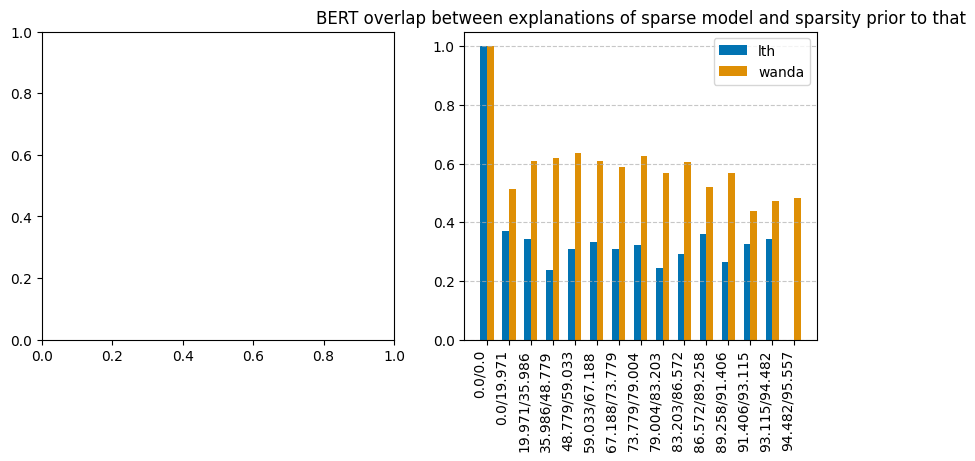

In [18]:
def get_concepts_across_cluster(model, method, filename):
    explanations = collections.defaultdict(set)
    sparsity_list = sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/"))
    for sparsity in sparsity_list:
        if '.ipy' in sparsity: continue
        sparsity = sparsity.split("%")[0]
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{sparsity}%Pruned/Cluster{expl_clus}IOUS1024N.csv")
        for _,concepts in get_indiv_concepts_per_unit(cluster3_expls).items():
            explanations[float(sparsity)].update(concepts)
        
        if float(sparsity) >= 82 and float(sparsity) <= 87:
            print(method, sparsity, len(explanations[float(sparsity)]))
    return explanations

def overlap(cur, prev):
    intersection = len(cur.intersection(prev))
    union = len(cur.union(prev))
    print(intersection, union, intersection/union)
    
    return intersection / union if union > 0 else 0


fig, axs = plt.subplots(1,2, figsize=(10, 4))  # 1 row, 2 columns
import numpy as np
'''
model='BERT'
method='wanda'
filename='Run3'
global_concepts = get_concepts_across_cluster(model, method, filename)
x=get_sparsities(model, method, filename)   
base_concepts = global_concepts[0.0]
sps = list(global_concepts.keys())

bert_overlap_between_sparse_and_base_wanda= []
for i,sparsity in enumerate(global_concepts.keys()):
    if i-1 >= 0:
        bert_overlap_between_sparse_and_base_wanda.append(overlap(global_concepts[sparsity], global_concepts[sps[i-1]]))
    else:
        bert_overlap_between_sparse_and_base_wanda.append(overlap(global_concepts[sparsity], base_concepts))
       
model='BERT'        
method='lottery_ticket'
filename='Run3'
global_concepts = get_concepts_across_cluster(model, method, filename)
x=get_sparsities(model, method, filename)   
base_concepts = global_concepts[0.0]
sps = list(global_concepts.keys())
bert_overlap_between_sparse_and_base_lth= []
print(sps)
for i,sparsity in enumerate(global_concepts.keys()):
    if i-1 >= 0:
        print("Comparing sparsity ", sparsity, " with ", sps[i-1])
        bert_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], global_concepts[sps[i-1]]))
    else:
        bert_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], base_concepts))
     

x_axis=get_sparsities(model, method, filename)        
x = ["0.0/0.0"]+[f"{x_axis[j]}/{x_axis[j+1]}" for j in range(len(x_axis) - 1)]        
x_pos = np.arange(len(x))  # Numeric positions for bars

bar_width = 0.3

# Plot grouped bars with offsets
axs[0].bar(x_pos - bar_width/2, bert_overlap_between_sparse_and_base_lth, 
           label='lth', color='#0173b2', width=bar_width)

axs[0].bar(x_pos + bar_width/2, bert_overlap_between_sparse_and_base_wanda, 
           label='wanda',color='#de8f05', width=bar_width)

axs[0].set_title('BERT overlap between explanations of sparse model and sparsity prior to that')
axs[0].legend()
axs[0].grid(True, axis='y', linestyle='--', alpha=0.7)
axs[0].set_xticks(x_pos)
axs[0].set_xticklabels(x, rotation=90, ha='right')
'''

model='BOWMAN'
method='wanda'
filename='Run1'
global_concepts = get_concepts_across_cluster(model, method, filename)
x_axis_w=get_sparsities(model, method, filename)   
base_concepts = global_concepts[0.0]
sps = list(global_concepts.keys())
bowman_overlap_between_sparse_and_base_wanda= []
for i,sparsity in enumerate(global_concepts.keys()):
    if i-1 >= 0:
        bowman_overlap_between_sparse_and_base_wanda.append(overlap(global_concepts[sparsity], global_concepts[sps[i-1]]))
    else:
        bowman_overlap_between_sparse_and_base_wanda.append(overlap(global_concepts[sparsity], base_concepts))
        
model='BOWMAN'        
method='lottery_ticket'
filename='Run1'
global_concepts = get_concepts_across_cluster(model, method, filename)   
base_concepts = global_concepts[0.0]
sps = list(global_concepts.keys())
bowman_overlap_between_sparse_and_base_lth= []
for i,sparsity in enumerate(global_concepts.keys()):
    if i-1 >= 0:
        #print("Comparing sparsity ", sparsity, " with ", sps[i-1])
        bowman_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], global_concepts[sps[i-1]]))
    else:
        bowman_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], base_concepts))
        

x_axis_l=get_sparsities(model, method, filename)        
x = ["0.0/0.0"]+[f"{x_axis_l[j]}/{x_axis_l[j+1]}" for j in range(len(x_axis_l) - 1)]        
x_pos_l = np.arange(len(x))  # Numeric positions for bars

   
x = ["0.0/0.0"]+[f"{x_axis_w[j]}/{x_axis_w[j+1]}" for j in range(len(x_axis_w) - 1)]        
x_pos_w = np.arange(len(x))  # Numeric positions for bars

bar_width = 0.3

# Plot grouped bars with offsets
axs[1].bar(x_pos_l - bar_width/2, bowman_overlap_between_sparse_and_base_lth, 
           label='lth', color='#0173b2', width=bar_width)

axs[1].bar(x_pos_w + bar_width/2, bowman_overlap_between_sparse_and_base_wanda, 
           label='wanda',color='#de8f05', width=bar_width)

axs[1].set_title('BERT overlap between explanations of sparse model and sparsity prior to that')
axs[1].legend()
axs[1].grid(True, axis='y', linestyle='--', alpha=0.7)
axs[1].set_xticks(x_pos_w)
axs[1].set_xticklabels(x, rotation=90, ha='right')

# global overlap: % of concepts in prev that carry over to next

26 26 1.0
20 39 0.5128205128205128
25 41 0.6097560975609756
26 42 0.6190476190476191
28 44 0.6363636363636364
28 46 0.6086956521739131
27 46 0.5869565217391305
30 48 0.625
30 53 0.5660377358490566
29 48 0.6041666666666666
25 48 0.5208333333333334
29 51 0.5686274509803921
25 57 0.43859649122807015
25 53 0.4716981132075472
26 54 0.48148148148148145
26 26 1.0
20 54 0.37037037037037035
26 76 0.34210526315789475
19 80 0.2375
22 71 0.30985915492957744
26 78 0.3333333333333333
25 81 0.30864197530864196
28 87 0.3218390804597701
27 111 0.24324324324324326
32 110 0.2909090909090909
36 100 0.36
30 113 0.26548672566371684
36 111 0.32432432432432434
43 126 0.3412698412698413


[Text(0, 0, '0.0/0.0'),
 Text(1, 0, '19.971/0.0'),
 Text(2, 0, '35.986/19.971'),
 Text(3, 0, '48.779/35.986'),
 Text(4, 0, '59.033/48.779'),
 Text(5, 0, '67.188/59.033'),
 Text(6, 0, '73.779/67.188'),
 Text(7, 0, '79.004/73.779'),
 Text(8, 0, '83.203/79.004'),
 Text(9, 0, '86.572/83.203'),
 Text(10, 0, '89.258/86.572'),
 Text(11, 0, '91.406/89.258'),
 Text(12, 0, '93.115/91.406'),
 Text(13, 0, '94.482/93.115'),
 Text(14, 0, '95.557/94.482')]

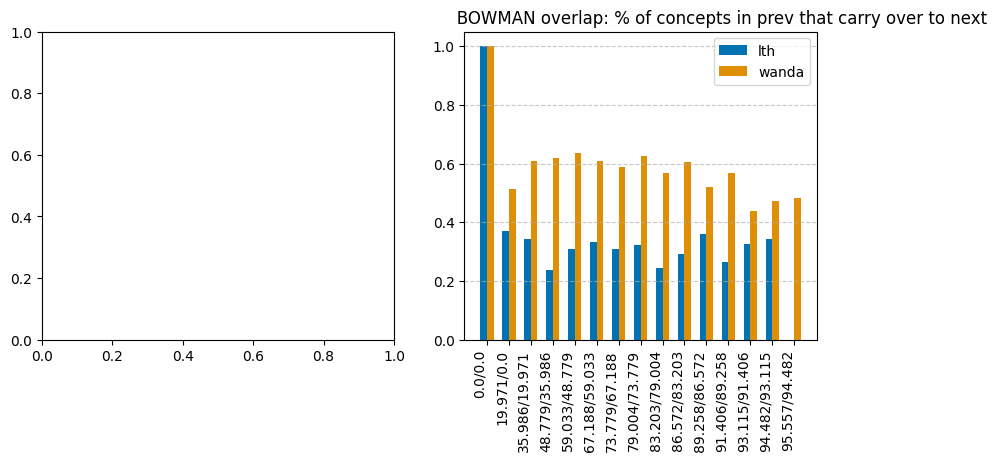

In [20]:
def get_concepts_across_cluster(model, method, filename):
    explanations = collections.defaultdict(set)
    sparsity_list = sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/"))
    for sparsity in sparsity_list:
        if '.ipy' in sparsity: continue
        sparsity = sparsity.split("%")[0]
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{sparsity}%Pruned/Cluster{expl_clus}IOUS1024N.csv")
        for _,concepts in get_indiv_concepts_per_unit(cluster3_expls).items():
            explanations[float(sparsity)].update(concepts)
    return explanations

def entailement(cur, prev):
    ct=0
    for i in prev:
        if i in cur:
            ct +=1
    return ct/len(prev)


fig, axs = plt.subplots(1,2, figsize=(10, 4))  # 1 row, 2 columns
import numpy as np
'''
model='BERT'
method='wanda'
filename='Run2Full'
global_concepts = get_concepts_across_cluster(model, method, filename)

base_concepts = global_concepts[0.0]
sps = list(global_concepts.keys())

bert_overlap_between_sparse_and_base_wanda= []
for i,sparsity in enumerate(global_concepts.keys()):
    
    if i-1 >= 0:
        
        print(f"cur= {sparsity}, pre= {sps[i-1]} ")
        bert_overlap_between_sparse_and_base_wanda.append(entailement(global_concepts[sparsity], global_concepts[sps[i-1]]))
    else:
        print(f"cur= {sparsity}, pre= 0 ")
        bert_overlap_between_sparse_and_base_wanda.append(entailement(global_concepts[sparsity],base_concepts))
        
model='BERT'        
method='lottery_ticket'
filename='Run2Full'
global_concepts = get_concepts_across_cluster(model, method, filename)

base_concepts = global_concepts[0.0]
sps = list(global_concepts.keys())
bert_overlap_between_sparse_and_base_lth= []
print(sps)
for i,sparsity in enumerate(global_concepts.keys()):
    if i-1 >= 0:
        print("Comparing sparsity ", sparsity, " with ", sps[i-1])
        bert_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], global_concepts[sps[i-1]]))
    else:
        bert_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], base_concepts))
     

'''
model='BOWMAN'
method='wanda'
filename='Run1'
global_concepts = get_concepts_across_cluster(model, method, filename)

base_concepts = global_concepts[0.0]
sps = list(global_concepts.keys())
bowman_overlap_between_sparse_and_base_wanda= []
for i,sparsity in enumerate(global_concepts.keys()):
    if i-1 >= 0:
        bowman_overlap_between_sparse_and_base_wanda.append(overlap(global_concepts[sparsity], global_concepts[sps[i-1]]))
    else:
        bowman_overlap_between_sparse_and_base_wanda.append(overlap(global_concepts[sparsity], base_concepts))
x_axis_w=get_sparsities(model, method, filename)       
x_w = ["0.0/0.0"]+[f"{x_axis_w[j]}/{x_axis_w[j-1]}" for j in range(1,len(x_axis_w))]        
x_pos_w = np.arange(len(x_w))  # Numeric positions for bars
 

model='BOWMAN'        
method='lottery_ticket'
filename='Run1'
global_concepts = get_concepts_across_cluster(model, method, filename)

base_concepts = global_concepts[0.0]
sps = list(global_concepts.keys())
bowman_overlap_between_sparse_and_base_lth= []
for i,sparsity in enumerate(global_concepts.keys()):
    if i-1 >=0:
        #print("Comparing sparsity ", sparsity, " with ", sps[i-1])
        bowman_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], global_concepts[sps[i-1]]))
    else:
        bowman_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], base_concepts))


x_axis_l=get_sparsities(model, method, filename)       
x_l = ["0.0/0.0"]+[f"{x_axis_l[j]}/{x_axis_l[j-1]}" for j in range(1,len(x_axis_l))]        
x_pos_l = np.arange(len(x_l))  # Numeric positions for bars

bar_width = 0.3
'''
# Plot grouped bars with offsets
axs[0].bar(x_pos - bar_width/2, bert_overlap_between_sparse_and_base_lth, 
           label='lth', color='#0173b2', width=bar_width)

axs[0].bar(x_pos + bar_width/2, bert_overlap_between_sparse_and_base_wanda, 
           label='wanda',color='#de8f05', width=bar_width)

axs[0].set_title('BERT overlap: % of concepts in prev that carry over to next')
axs[0].legend()
axs[0].grid(True, axis='y', linestyle='--', alpha=0.7)
axs[0].set_xticks(x_pos_l)
axs[0].set_xticklabels(x_l, rotation=90, ha='right')


'''
axs[1].bar(x_pos_l - bar_width/2, bowman_overlap_between_sparse_and_base_lth, 
           label='lth', color='#0173b2', width=bar_width)

axs[1].bar(x_pos_w + bar_width/2, bowman_overlap_between_sparse_and_base_wanda, 
           label='wanda',color='#de8f05', width=bar_width)

axs[1].set_title('                               BOWMAN overlap: % of concepts in prev that carry over to next')
axs[1].legend()
axs[1].grid(True, axis='y', linestyle='--', alpha=0.7)
axs[1].set_xticks(x_pos_w)
axs[1].set_xticklabels(x_w, rotation=90, ha='right')

In [ ]:
#every subseq iteration has rougly 60% of concepts preserved fromthe prev iter lthbert

#bowman 30% overlap between subseq pruning iters
bowman looses more concepts with pruning? or at least it doesnt preserve concepts as bert does cuz global overalp is very low
and locally after pruning % of concepts preserved drastially drops

the increase at 83/86 means those sparsities expl more sim cps than 79/83